In [1]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    "D:/我的/大学/量化/Multi-Factor-Investment-Strategy"
)

FACTOR_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "11_sp500_monthly_factor_scores_full_2005_2025.parquet"
)

SP500_COMPOSITE_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "crsp"
    / "05a_sp500_composite_monthly.csv"
)

SP500_VALUE_WEIGHTED_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "crsp"
    / "05b_crsp_sp500_value_weighted.csv"
)

SP500_EQUAL_WEIGHTED_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "crsp"
    / "05c_crsp_sp500_equal_weighted.csv"
)

TABLE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)

FIGURE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

TABLE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Factor file exists: {FACTOR_FILE.exists()}")
print(
    "S&P 500 Composite file exists: "
    f"{SP500_COMPOSITE_FILE.exists()}"
)
print(
    "CRSP value-weighted file exists: "
    f"{SP500_VALUE_WEIGHTED_FILE.exists()}"
)
print(
    "CRSP equal-weighted file exists: "
    f"{SP500_EQUAL_WEIGHTED_FILE.exists()}"
)

Factor file exists: True
S&P 500 Composite file exists: True
CRSP value-weighted file exists: True
CRSP equal-weighted file exists: True


In [2]:
benchmark_files = {
    "S&P 500 Composite": (
        SP500_COMPOSITE_FILE
    ),
    "CRSP S&P 500 Value Weighted": (
        SP500_VALUE_WEIGHTED_FILE
    ),
    "CRSP S&P 500 Equal Weighted": (
        SP500_EQUAL_WEIGHTED_FILE
    ),
}

for benchmark_name, benchmark_file in benchmark_files.items():

    with benchmark_file.open(
        mode="r",
        encoding="utf-8-sig",
        newline="",
    ) as file:
        reader = csv.reader(file)
        column_names = next(reader)

    print(f"\n{benchmark_name}")
    print(
        f"Number of columns: "
        f"{len(column_names)}"
    )

    for number, column_name in enumerate(
        column_names,
        start=1,
    ):
        print(
            f"{number:02d}. {column_name}"
        )


S&P 500 Composite
Number of columns: 12
01. INDNO
02. YYYYMM
03. MthCalDt
04. MthTotRet
05. MthTotInd
06. MthPrcRet
07. MthPrcInd
08. MthIncRet
09. MthIncInd
10. MthTotCnt
11. MthTotVal
12. IndNm

CRSP S&P 500 Value Weighted
Number of columns: 12
01. INDNO
02. YYYYMM
03. MthCalDt
04. MthTotRet
05. MthTotInd
06. MthPrcRet
07. MthPrcInd
08. MthIncRet
09. MthIncInd
10. MthTotCnt
11. MthTotVal
12. IndNm

CRSP S&P 500 Equal Weighted
Number of columns: 12
01. INDNO
02. YYYYMM
03. MthCalDt
04. MthTotRet
05. MthTotInd
06. MthPrcRet
07. MthPrcInd
08. MthIncRet
09. MthIncInd
10. MthTotCnt
11. MthTotVal
12. IndNm


In [7]:
def load_crsp_benchmark(
    file_path,
    source_return_column,
    output_return_column,
):
    benchmark_df = pd.read_csv(
        file_path
    )

    benchmark_df.columns = [
        column.lower()
        for column in benchmark_df.columns
    ]

    source_return_column = (
        source_return_column.lower()
    )

    benchmark_df["month"] = (
        pd.to_datetime(
            benchmark_df["mthcaldt"],
            errors="coerce",
        )
        + pd.offsets.MonthEnd(0)
    )

    benchmark_df[
        output_return_column
    ] = pd.to_numeric(
        benchmark_df[
            source_return_column
        ],
        errors="coerce",
    )

    index_information = (
        benchmark_df[
            [
                "indno",
                "indnm",
            ]
        ]
        .drop_duplicates()
    )

    print(f"\nFile: {file_path.name}")
    print(
        f"Return source: "
        f"{source_return_column}"
    )
    print("Index information:")
    print(
        index_information
        .to_string(index=False)
    )

    non_missing_returns = benchmark_df[
        output_return_column
    ].notna().sum()

    print(
        "Non-missing returns: "
        f"{non_missing_returns:,}"
    )

    if non_missing_returns == 0:
        raise ValueError(
            f"No valid returns found in "
            f"{source_return_column}."
        )

    return (
        benchmark_df[
            [
                "month",
                output_return_column,
            ]
        ]
        .dropna(
            subset=["month"]
        )
        .drop_duplicates(
            subset=["month"],
            keep="last",
        )
        .sort_values("month")
        .reset_index(drop=True)
    )

In [8]:
sp500_composite_df = load_crsp_benchmark(
    file_path=SP500_COMPOSITE_FILE,
    source_return_column="MthPrcRet",
    output_return_column=(
        "sp500_composite_price_return"
    ),
)

sp500_value_weighted_df = (
    load_crsp_benchmark(
        file_path=(
            SP500_VALUE_WEIGHTED_FILE
        ),
        source_return_column="MthTotRet",
        output_return_column=(
            "crsp_value_weighted_total_return"
        ),
    )
)

sp500_equal_weighted_df = (
    load_crsp_benchmark(
        file_path=(
            SP500_EQUAL_WEIGHTED_FILE
        ),
        source_return_column="MthTotRet",
        output_return_column=(
            "crsp_equal_weighted_total_return"
        ),
    )
)


File: 05a_sp500_composite_monthly.csv
Return source: mthprcret
Index information:
  indno             indnm
1000502 S&P 500 Composite
Non-missing returns: 276

File: 05b_crsp_sp500_value_weighted.csv
Return source: mthtotret
Index information:
  indno                                             indnm
1000500 CRSP Value-Weighted Index of the S&P 500 Universe
Non-missing returns: 276

File: 05c_crsp_sp500_equal_weighted.csv
Return source: mthtotret
Index information:
  indno                                             indnm
1000501 CRSP Equal-Weighted Index of the S&P 500 Universe
Non-missing returns: 276


In [9]:
benchmark_returns_df = (
    sp500_composite_df
    .merge(
        sp500_value_weighted_df,
        on="month",
        how="outer",
        validate="one_to_one",
    )
    .merge(
        sp500_equal_weighted_df,
        on="month",
        how="outer",
        validate="one_to_one",
    )
    .sort_values("month")
    .reset_index(drop=True)
)

benchmark_returns_df = (
    benchmark_returns_df.loc[
        benchmark_returns_df[
            "month"
        ].between(
            pd.Timestamp("2005-01-31"),
            pd.Timestamp("2025-12-31"),
        )
    ]
    .reset_index(drop=True)
)

print("Clean benchmark summary:")
print(
    f"Number of months: "
    f"{len(benchmark_returns_df)}"
)

print("\nMissing values:")
print(
    benchmark_returns_df
    .isna()
    .sum()
    .to_string()
)

print("\nMonthly return summary:")
print(
    benchmark_returns_df[
        [
            "sp500_composite_price_return",
            "crsp_value_weighted_total_return",
            "crsp_equal_weighted_total_return",
        ]
    ]
    .describe()
    .round(4)
    .to_string()
)

Clean benchmark summary:
Number of months: 252

Missing values:
month                               0
sp500_composite_price_return        0
crsp_value_weighted_total_return    0
crsp_equal_weighted_total_return    0

Monthly return summary:
       sp500_composite_price_return  crsp_value_weighted_total_return  crsp_equal_weighted_total_return
count                      252.0000                          252.0000                          252.0000
mean                         0.0078                            0.0095                            0.0094
std                          0.0428                            0.0427                            0.0492
min                         -0.1694                           -0.1670                           -0.2076
25%                         -0.0160                           -0.0145                           -0.0165
50%                          0.0127                            0.0148                            0.0119
75%                          0.

In [10]:
BENCHMARK_PARQUET_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "12_benchmark_returns_monthly_2005_2025.parquet"
)

BENCHMARK_CSV_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "12_benchmark_returns_monthly_2005_2025.csv"
)

benchmark_returns_df.to_parquet(
    BENCHMARK_PARQUET_FILE,
    index=False,
)

benchmark_returns_df.to_csv(
    BENCHMARK_CSV_FILE,
    index=False,
)

print("Clean benchmark datasets saved successfully.")
print(f"Parquet file: {BENCHMARK_PARQUET_FILE}")
print(f"CSV file: {BENCHMARK_CSV_FILE}")

Clean benchmark datasets saved successfully.
Parquet file: D:\我的\大学\量化\Multi-Factor-Investment-Strategy\data\processed\12_benchmark_returns_monthly_2005_2025.parquet
CSV file: D:\我的\大学\量化\Multi-Factor-Investment-Strategy\data\processed\12_benchmark_returns_monthly_2005_2025.csv


In [11]:
factor_portfolio_df = pd.read_parquet(
    FACTOR_FILE
)

factor_portfolio_df["month"] = pd.to_datetime(
    factor_portfolio_df["month"]
)

factor_portfolio_df = (
    factor_portfolio_df.loc[
        factor_portfolio_df[
            "is_member_month_end"
        ].fillna(False)
    ]
    .sort_values([
        "month",
        "permno",
    ])
    .reset_index(drop=True)
)

FORMATION_START = pd.Timestamp(
    "2014-12-31"
)

FORMATION_END = pd.Timestamp(
    "2025-11-30"
)

portfolio_formation_df = (
    factor_portfolio_df.loc[
        factor_portfolio_df[
            "month"
        ].between(
            FORMATION_START,
            FORMATION_END,
        )
    ]
    .copy()
)

portfolio_formation_df[
    "return_month"
] = (
    portfolio_formation_df["month"]
    + pd.offsets.MonthEnd(1)
)

print("Portfolio formation dataset created.")
print(
    f"Number of formation rows: "
    f"{len(portfolio_formation_df):,}"
)
print(
    f"Number of formation months: "
    f"{portfolio_formation_df['month'].nunique()}"
)
print(
    "Formation date range: "
    f"{portfolio_formation_df['month'].min().date()} "
    f"to {portfolio_formation_df['month'].max().date()}"
)
print(
    "Return date range: "
    f"{portfolio_formation_df['return_month'].min().date()} "
    f"to {portfolio_formation_df['return_month'].max().date()}"
)

Portfolio formation dataset created.
Number of formation rows: 66,546
Number of formation months: 132
Formation date range: 2014-12-31 to 2025-11-30
Return date range: 2015-01-31 to 2025-12-31


In [12]:
TOP_FRACTION = 0.20

target_weight_records = []


def append_target_weights(
    selected_sample,
    strategy_name,
    weighting_method,
    score_column=None,
):
    selected_sample = (
        selected_sample
        .drop_duplicates(
            subset=["permno"]
        )
        .copy()
    )

    number_of_stocks = len(
        selected_sample
    )

    if number_of_stocks == 0:
        return

    if weighting_method == "equal":
        target_weights = np.repeat(
            1.0 / number_of_stocks,
            number_of_stocks,
        )

    elif weighting_method == "value":
        valid_market_cap = (
            selected_sample[
                "month_end_market_cap"
            ]
            .where(
                selected_sample[
                    "month_end_market_cap"
                ] > 0
            )
        )

        valid_mask = (
            valid_market_cap.notna()
        )

        selected_sample = (
            selected_sample.loc[
                valid_mask
            ]
            .copy()
        )

        valid_market_cap = (
            valid_market_cap.loc[
                valid_mask
            ]
        )

        if len(selected_sample) == 0:
            return

        target_weights = (
            valid_market_cap
            / valid_market_cap.sum()
        ).to_numpy()

    else:
        raise ValueError(
            "Unknown weighting method."
        )

    for row, target_weight in zip(
        selected_sample.itertuples(
            index=False
        ),
        target_weights,
    ):
        if score_column is None:
            signal_value = np.nan
        else:
            signal_value = getattr(
                row,
                score_column,
            )

        target_weight_records.append({
            "formation_month": row.month,
            "return_month": row.return_month,
            "strategy": strategy_name,
            "permno": row.permno,
            "ticker": row.ticker,
            "target_weight": (
                float(target_weight)
            ),
            "signal_value": signal_value,
            "future_return_1m": (
                row.future_return_1m
            ),
            "future_return_missing": (
                pd.isna(
                    row.future_return_1m
                )
            ),
        })

In [13]:
for formation_month, month_group in (
    portfolio_formation_df.groupby(
        "month",
        sort=True,
    )
):
    month_group = (
        month_group
        .sort_values("permno")
        .copy()
    )

    # 1. Entire universe, equal weighted
    append_target_weights(
        selected_sample=month_group,
        strategy_name=(
            "Universe Equal Weight"
        ),
        weighting_method="equal",
    )

    # 2. Entire universe, value weighted
    append_target_weights(
        selected_sample=month_group,
        strategy_name=(
            "Universe Value Weight"
        ),
        weighting_method="value",
    )

    # 3. Six-factor top quintile
    multi_factor_eligible = (
        month_group
        .dropna(
            subset=[
                "multi_factor_score"
            ]
        )
        .sort_values(
            [
                "multi_factor_score",
                "permno",
            ],
            ascending=[
                False,
                True,
            ],
        )
    )

    multi_factor_count = max(
        1,
        int(
            np.ceil(
                len(multi_factor_eligible)
                * TOP_FRACTION
            )
        ),
    )

    multi_factor_selected = (
        multi_factor_eligible.head(
            multi_factor_count
        )
    )

    append_target_weights(
        selected_sample=(
            multi_factor_selected
        ),
        strategy_name=(
            "Six-Factor Top Quintile"
        ),
        weighting_method="equal",
        score_column=(
            "multi_factor_score"
        ),
    )

    # 4. Quality top quintile
    quality_eligible = (
        month_group
        .dropna(
            subset=[
                "factor_quality"
            ]
        )
        .sort_values(
            [
                "factor_quality",
                "permno",
            ],
            ascending=[
                False,
                True,
            ],
        )
    )

    quality_count = max(
        1,
        int(
            np.ceil(
                len(quality_eligible)
                * TOP_FRACTION
            )
        ),
    )

    quality_selected = (
        quality_eligible.head(
            quality_count
        )
    )

    append_target_weights(
        selected_sample=(
            quality_selected
        ),
        strategy_name=(
            "Quality Top Quintile"
        ),
        weighting_method="equal",
        score_column="factor_quality",
    )

target_weights_df = pd.DataFrame(
    target_weight_records
)

target_weights_df = (
    target_weights_df
    .sort_values([
        "strategy",
        "formation_month",
        "permno",
    ])
    .reset_index(drop=True)
)

print("Target portfolio weights created.")
print(
    f"Number of holding records: "
    f"{len(target_weights_df):,}"
)

Target portfolio weights created.
Number of holding records: 158,967


In [14]:
weight_validation_df = (
    target_weights_df
    .groupby([
        "strategy",
        "formation_month",
    ])
    .agg(
        weight_sum=(
            "target_weight",
            "sum",
        ),
        number_of_holdings=(
            "permno",
            "nunique",
        ),
        missing_future_returns=(
            "future_return_missing",
            "sum",
        ),
    )
    .reset_index()
)

maximum_weight_sum_error = (
    weight_validation_df[
        "weight_sum"
    ]
    .sub(1.0)
    .abs()
    .max()
)

print("Target-weight validation:")
print(
    "Maximum absolute weight-sum error: "
    f"{maximum_weight_sum_error:.12f}"
)

print("\nAverage holdings by strategy:")
print(
    weight_validation_df
    .groupby("strategy")[
        "number_of_holdings"
    ]
    .mean()
    .round(2)
    .to_string()
)

print("\nTotal missing future returns by strategy:")
print(
    weight_validation_df
    .groupby("strategy")[
        "missing_future_returns"
    ]
    .sum()
    .to_string()
)

if maximum_weight_sum_error > 1e-8:
    raise ValueError(
        "Portfolio weights do not sum to one."
    )

Target-weight validation:
Maximum absolute weight-sum error: 0.000000000000

Average holdings by strategy:
strategy
Quality Top Quintile        96.17
Six-Factor Top Quintile     99.85
Universe Equal Weight      504.14
Universe Value Weight      504.14

Total missing future returns by strategy:
strategy
Quality Top Quintile        3
Six-Factor Top Quintile     7
Universe Equal Weight      25
Universe Value Weight      25


In [15]:
TRANSACTION_COST_RATE = 0.001


def backtest_strategy_with_costs(
    strategy_weights,
    transaction_cost_rate,
):
    strategy_weights = (
        strategy_weights
        .sort_values([
            "formation_month",
            "permno",
        ])
        .copy()
    )

    monthly_result_records = []

    previous_drifted_weights = None

    for formation_month, month_weights in (
        strategy_weights.groupby(
            "formation_month",
            sort=True,
        )
    ):
        month_weights = (
            month_weights
            .set_index("permno")
            .copy()
        )

        target_weights = (
            month_weights[
                "target_weight"
            ]
            .astype(float)
        )

        realized_stock_returns = (
            month_weights[
                "future_return_1m"
            ]
            .fillna(0.0)
            .astype(float)
        )

        if previous_drifted_weights is None:
            turnover = 1.0
        else:
            combined_permnos = (
                target_weights.index.union(
                    previous_drifted_weights.index
                )
            )

            current_aligned = (
                target_weights.reindex(
                    combined_permnos,
                    fill_value=0.0,
                )
            )

            previous_aligned = (
                previous_drifted_weights.reindex(
                    combined_permnos,
                    fill_value=0.0,
                )
            )

            turnover = (
                0.5
                * (
                    current_aligned
                    - previous_aligned
                )
                .abs()
                .sum()
            )

        gross_return = float(
            (
                target_weights
                * realized_stock_returns
            ).sum()
        )

        transaction_cost = (
            transaction_cost_rate
            * turnover
        )

        net_return = (
            (1.0 - transaction_cost)
            * (1.0 + gross_return)
            - 1.0
        )

        end_of_period_values = (
            target_weights
            * (
                1.0
                + realized_stock_returns
            )
        )

        total_end_value = (
            end_of_period_values.sum()
        )

        if total_end_value > 0:
            previous_drifted_weights = (
                end_of_period_values
                / total_end_value
            )
        else:
            previous_drifted_weights = (
                target_weights.copy()
            )

        monthly_result_records.append({
            "formation_month": (
                formation_month
            ),
            "return_month": (
                month_weights[
                    "return_month"
                ].iloc[0]
            ),
            "number_of_holdings": (
                len(month_weights)
            ),
            "missing_return_holdings": (
                month_weights[
                    "future_return_missing"
                ].sum()
            ),
            "turnover": turnover,
            "transaction_cost": (
                transaction_cost
            ),
            "gross_return": gross_return,
            "net_return": net_return,
        })

    return pd.DataFrame(
        monthly_result_records
    )

In [16]:
strategy_backtest_results = []

for strategy_name, strategy_weights in (
    target_weights_df.groupby(
        "strategy",
        sort=True,
    )
):
    strategy_result = (
        backtest_strategy_with_costs(
            strategy_weights=(
                strategy_weights
            ),
            transaction_cost_rate=(
                TRANSACTION_COST_RATE
            ),
        )
    )

    strategy_result[
        "strategy"
    ] = strategy_name

    strategy_backtest_results.append(
        strategy_result
    )

strategy_monthly_returns_df = pd.concat(
    strategy_backtest_results,
    ignore_index=True,
)

strategy_monthly_returns_df = (
    strategy_monthly_returns_df
    .sort_values([
        "strategy",
        "return_month",
    ])
    .reset_index(drop=True)
)

print("Strategy backtests completed successfully.")
print(
    f"Number of strategy-month records: "
    f"{len(strategy_monthly_returns_df):,}"
)

Strategy backtests completed successfully.
Number of strategy-month records: 528


In [17]:
strategy_backtest_df = (
    strategy_monthly_returns_df
    .merge(
        benchmark_returns_df,
        left_on="return_month",
        right_on="month",
        how="left",
        validate="many_to_one",
    )
    .drop(columns=["month"])
)

backtest_summary_check = (
    strategy_backtest_df
    .groupby("strategy")
    .agg(
        number_of_months=(
            "return_month",
            "nunique",
        ),
        average_holdings=(
            "number_of_holdings",
            "mean",
        ),
        average_turnover=(
            "turnover",
            "mean",
        ),
        average_gross_return=(
            "gross_return",
            "mean",
        ),
        average_net_return=(
            "net_return",
            "mean",
        ),
        total_missing_return_holdings=(
            "missing_return_holdings",
            "sum",
        ),
    )
)

print("Backtest summary check:")
print(
    backtest_summary_check
    .round(4)
    .to_string()
)

print("\nMissing benchmark returns:")
print(
    strategy_backtest_df[
        [
            "sp500_composite_price_return",
            "crsp_value_weighted_total_return",
            "crsp_equal_weighted_total_return",
        ]
    ]
    .isna()
    .sum()
    .to_string()
)

Backtest summary check:
                         number_of_months  average_holdings  average_turnover  average_gross_return  average_net_return  total_missing_return_holdings
strategy                                                                                                                                              
Quality Top Quintile                  132           96.1742            0.0757                0.0111              0.0110                              3
Six-Factor Top Quintile               132           99.8485            0.1955                0.0088              0.0086                              7
Universe Equal Weight                 132          504.1364            0.0374                0.0094              0.0094                             25
Universe Value Weight                 132          504.1364            0.0113                0.0116              0.0116                             25

Missing benchmark returns:
sp500_composite_price_return        0
crsp

In [18]:
TARGET_WEIGHTS_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "13_strategy_target_weights_2014_2025.parquet"
)

STRATEGY_RETURNS_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "14_strategy_monthly_returns_2015_2025.csv"
)

target_weights_df.to_parquet(
    TARGET_WEIGHTS_FILE,
    index=False,
)

strategy_backtest_df.to_csv(
    STRATEGY_RETURNS_FILE,
    index=False,
)

print("Portfolio backtest datasets saved successfully.")
print(f"Target-weight file: {TARGET_WEIGHTS_FILE}")
print(f"Monthly-return file: {STRATEGY_RETURNS_FILE}")

Portfolio backtest datasets saved successfully.
Target-weight file: D:\我的\大学\量化\Multi-Factor-Investment-Strategy\data\processed\13_strategy_target_weights_2014_2025.parquet
Monthly-return file: D:\我的\大学\量化\Multi-Factor-Investment-Strategy\data\processed\14_strategy_monthly_returns_2015_2025.csv


In [19]:
from pathlib import Path
import csv
import re
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(
    r"D:/我的/大学/量化/Multi-Factor-Investment-Strategy"
)

FF5_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "fama_french"
    / "06_ff5_monthly.csv"
)

MOMENTUM_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "fama_french"
    / "07_momentum_monthly.csv"
)


def read_kenneth_french_monthly(file_path):
    with open(file_path, "r", encoding="latin-1") as file:
        lines = file.read().splitlines()

    header_index = None
    header = None

    for index, line in enumerate(lines):
        fields = [
            value.strip()
            for value in next(csv.reader([line]))
        ]

        normalized_fields = {
            value.lower().replace(" ", "")
            for value in fields
        }

        if (
            "mkt-rf" in normalized_fields
            or "mom" in normalized_fields
        ):
            header_index = index
            header = fields
            break

    if header_index is None:
        raise ValueError(
            f"Monthly factor header was not found in {file_path.name}."
        )

    if header[0] == "":
        header[0] = "yyyymm"

    records = []

    for line in lines[header_index + 1:]:
        fields = [
            value.strip()
            for value in next(csv.reader([line]))
        ]

        if not fields:
            continue

        if re.fullmatch(r"\d{6}", fields[0]):
            if len(fields) < len(header):
                fields = fields + [""] * (len(header) - len(fields))

            records.append(fields[:len(header)])

        elif records:
            break

    factor_df = pd.DataFrame(
        records,
        columns=header
    )

    factor_df.columns = [
        re.sub(
            r"[^a-z0-9]+",
            "_",
            column.lower()
        ).strip("_")
        for column in factor_df.columns
    ]

    factor_df["yyyymm"] = (
        factor_df["yyyymm"]
        .astype(str)
        .str.strip()
    )

    factor_df["month"] = (
        pd.to_datetime(
            factor_df["yyyymm"] + "01",
            format="%Y%m%d"
        )
        + pd.offsets.MonthEnd(0)
    )

    factor_columns = [
        column
        for column in factor_df.columns
        if column not in ["yyyymm", "month"]
    ]

    for column in factor_columns:
        factor_df[column] = (
            pd.to_numeric(
                factor_df[column],
                errors="coerce"
            )
            / 100.0
        )

    return (
        factor_df[
            ["month"] + factor_columns
        ]
        .sort_values("month")
        .reset_index(drop=True)
    )


ff5_df = read_kenneth_french_monthly(FF5_FILE)
momentum_df = read_kenneth_french_monthly(MOMENTUM_FILE)

print("Fama-French files were loaded successfully.")
print("FF5 columns:", ff5_df.columns.tolist())
print("Momentum columns:", momentum_df.columns.tolist())

Fama-French files were loaded successfully.
FF5 columns: ['month', 'mkt_rf', 'smb', 'hml', 'rmw', 'cma', 'rf']
Momentum columns: ['month', 'mom']


In [20]:
ff_monthly_df = (
    ff5_df
    .merge(
        momentum_df[["month", "mom"]],
        on="month",
        how="left",
        validate="one_to_one"
    )
    .query(
        "'2015-01-31' <= month <= '2025-12-31'"
    )
    .sort_values("month")
    .reset_index(drop=True)
)

required_factor_columns = [
    "mkt_rf",
    "smb",
    "hml",
    "rmw",
    "cma",
    "rf",
    "mom"
]

missing_columns = [
    column
    for column in required_factor_columns
    if column not in ff_monthly_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing Fama-French columns: {missing_columns}"
    )

if ff_monthly_df["month"].duplicated().any():
    raise ValueError(
        "Duplicate months were found in the factor data."
    )

if len(ff_monthly_df) != 132:
    raise ValueError(
        "The factor data should contain 132 months "
        "from January 2015 through December 2025."
    )

ff_missing_summary = (
    ff_monthly_df[
        ["month"] + required_factor_columns
    ]
    .isna()
    .sum()
)

print("Fama-French monthly data validation:")
print("Number of months:", len(ff_monthly_df))
print(
    "Date range:",
    ff_monthly_df["month"].min().date(),
    "to",
    ff_monthly_df["month"].max().date()
)
print("\nMissing values:")
print(ff_missing_summary)

display(ff_monthly_df.head())

Fama-French monthly data validation:
Number of months: 132
Date range: 2015-01-31 to 2025-12-31

Missing values:
month     0
mkt_rf    0
smb       0
hml       0
rmw       0
cma       0
rf        0
mom       0
dtype: int64


,month,mkt_rf,smb,hml,rmw,cma,rf,mom
0,2015-01-31,-0.0309,-0.0093,-0.0345,0.0158,-0.0164,0.0,0.0372
1,2015-02-28,0.0614,0.0036,-0.0179,-0.0110,-0.0175,0.0,-0.0289
2,2015-03-31,-0.0109,0.0308,-0.0038,0.0007,-0.0062,0.0,0.0270
3,2015-04-30,0.0060,-0.0301,0.0180,0.0005,-0.0062,0.0,-0.0726
4,2015-05-31,0.0138,0.0082,-0.0111,-0.0176,-0.0083,0.0,0.0576


In [21]:
PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

FF_PARQUET_FILE = (
    PROCESSED_DATA_DIR
    / "15_fama_french_monthly_2015_2025.parquet"
)

FF_CSV_FILE = (
    PROCESSED_DATA_DIR
    / "15_fama_french_monthly_2015_2025.csv"
)

ff_monthly_df.to_parquet(
    FF_PARQUET_FILE,
    index=False
)

ff_monthly_df.to_csv(
    FF_CSV_FILE,
    index=False
)

print("Clean Fama-French data was saved successfully.")
print("Parquet file:", FF_PARQUET_FILE)
print("CSV file:", FF_CSV_FILE)

Clean Fama-French data was saved successfully.
Parquet file: D:\我的\大学\量化\Multi-Factor-Investment-Strategy\data\processed\15_fama_french_monthly_2015_2025.parquet
CSV file: D:\我的\大学\量化\Multi-Factor-Investment-Strategy\data\processed\15_fama_french_monthly_2015_2025.csv


In [22]:
strategy_column_names = {
    "Quality Top Quintile":
        "quality_top_quintile",

    "Six-Factor Top Quintile":
        "six_factor_top_quintile",

    "Universe Equal Weight":
        "universe_equal_weight",

    "Universe Value Weight":
        "universe_value_weight"
}

strategy_net_wide_df = (
    strategy_backtest_df
    .pivot(
        index="return_month",
        columns="strategy",
        values="net_return"
    )
    .rename(columns=strategy_column_names)
    .rename_axis(columns=None)
    .reset_index()
)

strategy_net_wide_df = strategy_net_wide_df.rename(
    columns={
        column: f"{column}_net"
        for column in strategy_column_names.values()
    }
)

strategy_gross_wide_df = (
    strategy_backtest_df
    .pivot(
        index="return_month",
        columns="strategy",
        values="gross_return"
    )
    .rename(columns=strategy_column_names)
    .rename_axis(columns=None)
    .reset_index()
)

strategy_gross_wide_df = strategy_gross_wide_df.rename(
    columns={
        column: f"{column}_gross"
        for column in strategy_column_names.values()
    }
)

benchmark_evaluation_df = (
    benchmark_returns_df
    .rename(columns={"month": "return_month"})
    .query(
        "'2015-01-31' <= return_month <= '2025-12-31'"
    )
    .copy()
)

evaluation_return_df = (
    strategy_net_wide_df
    .merge(
        benchmark_evaluation_df,
        on="return_month",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        ff_monthly_df.rename(
            columns={"month": "return_month"}
        ),
        on="return_month",
        how="inner",
        validate="one_to_one"
    )
    .sort_values("return_month")
    .reset_index(drop=True)
)

if len(evaluation_return_df) != 132:
    raise ValueError(
        "The evaluation panel should contain 132 months."
    )

print("Strategy and benchmark return panel created successfully.")
print("Number of months:", len(evaluation_return_df))
print(
    "Date range:",
    evaluation_return_df["return_month"].min().date(),
    "to",
    evaluation_return_df["return_month"].max().date()
)

print("\nMissing values:")
print(evaluation_return_df.isna().sum())

display(evaluation_return_df.head())

Strategy and benchmark return panel created successfully.
Number of months: 132
Date range: 2015-01-31 to 2025-12-31

Missing values:
return_month                        0
quality_top_quintile_net            0
six_factor_top_quintile_net         0
universe_equal_weight_net           0
universe_value_weight_net           0
sp500_composite_price_return        0
crsp_value_weighted_total_return    0
crsp_equal_weighted_total_return    0
mkt_rf                              0
smb                                 0
hml                                 0
rmw                                 0
cma                                 0
rf                                  0
mom                                 0
dtype: int64


,return_month,quality_top_quintile_net,six_factor_top_quintile_net,universe_equal_weight_net,universe_value_weight_net,sp500_composite_price_return,crsp_value_weighted_total_return,crsp_equal_weighted_total_return,mkt_rf,smb,hml,rmw,cma,rf,mom
0,2015-01-31,-0.033751,-0.021044,-0.029116,-0.030312,-0.031041,-0.029430,-0.028079,-0.0309,-0.0093,-0.0345,0.0158,-0.0164,0.0,0.0372
1,2015-02-28,0.066744,0.048759,0.058530,0.056990,0.054893,0.056976,0.058577,0.0614,0.0036,-0.0179,-0.0110,-0.0175,0.0,-0.0289
2,2015-03-31,-0.008007,-0.004108,-0.009432,-0.015232,-0.017396,-0.014993,-0.008459,-0.0109,0.0308,-0.0038,0.0007,-0.0062,0.0,0.0270
3,2015-04-30,0.007565,-0.009939,0.004265,0.009182,0.008521,0.009101,0.003948,0.0060,-0.0301,0.0180,0.0005,-0.0062,0.0,-0.0726
4,2015-05-31,0.003409,0.010524,0.008727,0.012516,0.010491,0.012522,0.008756,0.0138,0.0082,-0.0111,-0.0176,-0.0083,0.0,0.0576


In [23]:
def calculate_performance_metrics(
    data,
    return_column,
    display_name
):
    sample = (
        data[
            ["return_month", return_column, "rf"]
        ]
        .dropna()
        .sort_values("return_month")
        .copy()
    )

    returns = sample[return_column].astype(float)
    excess_returns = returns - sample["rf"].astype(float)

    number_of_months = len(returns)

    wealth = (1.0 + returns).cumprod()
    terminal_wealth = wealth.iloc[-1]

    annualized_return = (
        terminal_wealth ** (12.0 / number_of_months)
        - 1.0
    )

    annualized_volatility = (
        returns.std(ddof=1)
        * np.sqrt(12.0)
    )

    annualized_excess_return = (
        excess_returns.mean()
        * 12.0
    )

    annualized_sharpe = (
        annualized_excess_return
        / (
            excess_returns.std(ddof=1)
            * np.sqrt(12.0)
        )
    )

    downside_returns = np.minimum(
        excess_returns,
        0.0
    )

    annualized_downside_deviation = (
        np.sqrt(np.mean(downside_returns ** 2))
        * np.sqrt(12.0)
    )

    annualized_sortino = (
        annualized_excess_return
        / annualized_downside_deviation
        if annualized_downside_deviation > 0
        else np.nan
    )

    drawdown = (
        wealth
        / wealth.cummax()
        - 1.0
    )

    maximum_drawdown = drawdown.min()

    calmar_ratio = (
        annualized_return
        / abs(maximum_drawdown)
        if maximum_drawdown < 0
        else np.nan
    )

    fifth_percentile = returns.quantile(0.05)

    value_at_risk_95 = -fifth_percentile

    expected_shortfall_95 = -returns[
        returns <= fifth_percentile
    ].mean()

    return {
        "series": display_name,
        "number_of_months": number_of_months,
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "annualized_sharpe": annualized_sharpe,
        "annualized_sortino": annualized_sortino,
        "maximum_drawdown": maximum_drawdown,
        "calmar_ratio": calmar_ratio,
        "monthly_var_95": value_at_risk_95,
        "monthly_cvar_95": expected_shortfall_95,
        "positive_month_rate": (returns > 0).mean(),
        "best_month": returns.max(),
        "worst_month": returns.min(),
        "terminal_wealth": terminal_wealth
    }


performance_series = {
    "quality_top_quintile_net":
        "Quality Top Quintile",

    "six_factor_top_quintile_net":
        "Six-Factor Top Quintile",

    "universe_equal_weight_net":
        "Universe Equal Weight",

    "universe_value_weight_net":
        "Universe Value Weight",

    "crsp_value_weighted_total_return":
        "CRSP S&P 500 Value Weighted",

    "crsp_equal_weighted_total_return":
        "CRSP S&P 500 Equal Weighted",

    "sp500_composite_price_return":
        "S&P 500 Composite Price Index"
}

performance_records = []

for return_column, display_name in performance_series.items():
    performance_records.append(
        calculate_performance_metrics(
            evaluation_return_df,
            return_column,
            display_name
        )
    )

performance_summary_df = (
    pd.DataFrame(performance_records)
    .set_index("series")
)

display_columns = [
    "annualized_return",
    "annualized_volatility",
    "annualized_sharpe",
    "annualized_sortino",
    "maximum_drawdown",
    "calmar_ratio",
    "monthly_var_95",
    "monthly_cvar_95",
    "positive_month_rate",
    "terminal_wealth"
]

print("Risk-adjusted performance summary:")
display(
    performance_summary_df[
        display_columns
    ].round(4)
)

Risk-adjusted performance summary:


,annualized_return,annualized_volatility,annualized_sharpe,annualized_sortino,maximum_drawdown,calmar_ratio,monthly_var_95,monthly_cvar_95,positive_month_rate,terminal_wealth
series,,,,,,,,,,
Quality Top Quintile,0.1251,0.1667,0.6779,1.0824,-0.2520,0.4962,0.0700,0.0999,0.6439,3.6553
Six-Factor Top Quintile,0.0941,0.1570,0.5319,0.7976,-0.2960,0.3178,0.0551,0.0984,0.6212,2.6889
Universe Equal Weight,0.1038,0.1650,0.5677,0.8672,-0.2749,0.3778,0.0655,0.1006,0.6439,2.9644
Universe Value Weight,0.1355,0.1497,0.8014,1.2600,-0.2370,0.5716,0.0655,0.0891,0.6970,4.0452
CRSP S&P 500 Value Weighted,0.1367,0.1498,0.8083,1.2727,-0.2367,0.5776,0.0655,0.0891,0.7045,4.0940
CRSP S&P 500 Equal Weighted,0.1060,0.1652,0.5796,0.8867,-0.2747,0.3861,0.0656,0.1007,0.6515,3.0304
S&P 500 Composite Price Index,0.1154,0.1497,0.6814,1.0444,-0.2477,0.4659,0.0674,0.0908,0.6667,3.3248


In [24]:
gross_benchmark_comparison_df = (
    strategy_gross_wide_df
    .merge(
        benchmark_evaluation_df,
        on="return_month",
        how="inner",
        validate="one_to_one"
    )
)

tracking_specifications = [
    {
        "portfolio":
            "Universe Value Weight",

        "internal_column":
            "universe_value_weight_gross",

        "benchmark_column":
            "crsp_value_weighted_total_return"
    },
    {
        "portfolio":
            "Universe Equal Weight",

        "internal_column":
            "universe_equal_weight_gross",

        "benchmark_column":
            "crsp_equal_weighted_total_return"
    }
]

tracking_records = []

for specification in tracking_specifications:
    internal_return = gross_benchmark_comparison_df[
        specification["internal_column"]
    ]

    benchmark_return = gross_benchmark_comparison_df[
        specification["benchmark_column"]
    ]

    active_return = (
        internal_return
        - benchmark_return
    )

    tracking_error = (
        active_return.std(ddof=1)
        * np.sqrt(12.0)
    )

    information_ratio = (
        active_return.mean()
        / active_return.std(ddof=1)
        * np.sqrt(12.0)
        if active_return.std(ddof=1) > 0
        else np.nan
    )

    tracking_records.append({
        "portfolio":
            specification["portfolio"],

        "return_correlation":
            internal_return.corr(benchmark_return),

        "annualized_active_return":
            active_return.mean() * 12.0,

        "annualized_tracking_error":
            tracking_error,

        "information_ratio":
            information_ratio,

        "maximum_absolute_monthly_difference":
            active_return.abs().max()
    })

tracking_summary_df = (
    pd.DataFrame(tracking_records)
    .set_index("portfolio")
)

print("Official benchmark tracking validation:")
display(tracking_summary_df.round(4))

Official benchmark tracking validation:


,return_correlation,annualized_active_return,annualized_tracking_error,information_ratio,maximum_absolute_monthly_difference
portfolio,,,,,
Universe Value Weight,1.0000,-0.0010,0.0013,-0.7762,0.0035
Universe Equal Weight,0.9999,-0.0016,0.0017,-0.9430,0.0034


In [25]:
def calculate_cagr(return_series):
    clean_returns = return_series.dropna()

    terminal_value = (
        1.0 + clean_returns
    ).prod()

    return (
        terminal_value
        ** (12.0 / len(clean_returns))
        - 1.0
    )


cost_impact_records = []

for strategy_name, group in strategy_backtest_df.groupby(
    "strategy"
):
    group = (
        group
        .sort_values("return_month")
        .copy()
    )

    gross_cagr = calculate_cagr(
        group["gross_return"]
    )

    net_cagr = calculate_cagr(
        group["net_return"]
    )

    cost_impact_records.append({
        "strategy":
            strategy_name,

        "average_monthly_turnover":
            group["turnover"].mean(),

        "gross_annualized_return":
            gross_cagr,

        "net_annualized_return":
            net_cagr,

        "annualized_cost_drag":
            gross_cagr - net_cagr,

        "annualized_cost_drag_bps":
            (gross_cagr - net_cagr) * 10000.0
    })

cost_impact_summary_df = (
    pd.DataFrame(cost_impact_records)
    .set_index("strategy")
)

print("Transaction-cost impact summary:")
display(cost_impact_summary_df.round(4))


PERFORMANCE_CSV_FILE = (
    PROCESSED_DATA_DIR
    / "16_portfolio_performance_summary_2015_2025.csv"
)

TRACKING_CSV_FILE = (
    PROCESSED_DATA_DIR
    / "17_benchmark_tracking_summary_2015_2025.csv"
)

COST_IMPACT_CSV_FILE = (
    PROCESSED_DATA_DIR
    / "18_transaction_cost_impact_2015_2025.csv"
)

EVALUATION_PANEL_PARQUET_FILE = (
    PROCESSED_DATA_DIR
    / "19_strategy_benchmark_evaluation_panel_2015_2025.parquet"
)

performance_summary_df.to_csv(
    PERFORMANCE_CSV_FILE
)

tracking_summary_df.to_csv(
    TRACKING_CSV_FILE
)

cost_impact_summary_df.to_csv(
    COST_IMPACT_CSV_FILE
)

evaluation_return_df.to_parquet(
    EVALUATION_PANEL_PARQUET_FILE,
    index=False
)

print("Portfolio evaluation files were saved successfully.")

Transaction-cost impact summary:


,average_monthly_turnover,gross_annualized_return,net_annualized_return,annualized_cost_drag,annualized_cost_drag_bps
strategy,,,,,
Quality Top Quintile,0.0757,0.1261,0.1251,0.0010,10.2308
Six-Factor Top Quintile,0.1955,0.0967,0.0941,0.0026,25.7007
Universe Equal Weight,0.0374,0.1043,0.1038,0.0005,4.9492
Universe Value Weight,0.0113,0.1356,0.1355,0.0002,1.5382


Portfolio evaluation files were saved successfully.


In [26]:
import statsmodels.api as sm

factor_regression_series = {
    "quality_top_quintile_net":
        "Quality Top Quintile",

    "six_factor_top_quintile_net":
        "Six-Factor Top Quintile",

    "universe_equal_weight_net":
        "Universe Equal Weight",

    "universe_value_weight_net":
        "Universe Value Weight",

    "crsp_value_weighted_total_return":
        "CRSP S&P 500 Value Weighted",

    "crsp_equal_weighted_total_return":
        "CRSP S&P 500 Equal Weighted"
}

factor_specifications = {
    "CAPM": [
        "mkt_rf"
    ],

    "Fama-French Five-Factor": [
        "mkt_rf",
        "smb",
        "hml",
        "rmw",
        "cma"
    ],

    "Fama-French Five-Factor plus Momentum": [
        "mkt_rf",
        "smb",
        "hml",
        "rmw",
        "cma",
        "mom"
    ]
}


def estimate_factor_regression(
    data,
    return_column,
    series_name,
    specification_name,
    factor_columns,
    maximum_hac_lag=3
):
    required_columns = (
        [return_column, "rf"]
        + factor_columns
    )

    regression_sample = (
        data[required_columns]
        .dropna()
        .copy()
    )

    dependent_variable = (
        regression_sample[return_column]
        - regression_sample["rf"]
    )

    independent_variables = sm.add_constant(
        regression_sample[factor_columns],
        has_constant="add"
    )

    model = sm.OLS(
        dependent_variable,
        independent_variables
    ).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": maximum_hac_lag
        }
    )

    result = {
        "series":
            series_name,

        "specification":
            specification_name,

        "number_of_months":
            int(model.nobs),

        "monthly_alpha":
            model.params["const"],

        "annualized_alpha":
            model.params["const"] * 12.0,

        "alpha_t_statistic":
            model.tvalues["const"],

        "alpha_p_value":
            model.pvalues["const"],

        "r_squared":
            model.rsquared,

        "adjusted_r_squared":
            model.rsquared_adj
    }

    all_factors = [
        "mkt_rf",
        "smb",
        "hml",
        "rmw",
        "cma",
        "mom"
    ]

    for factor in all_factors:
        result[f"{factor}_beta"] = (
            model.params[factor]
            if factor in model.params.index
            else np.nan
        )

        result[f"{factor}_t_statistic"] = (
            model.tvalues[factor]
            if factor in model.tvalues.index
            else np.nan
        )

        result[f"{factor}_p_value"] = (
            model.pvalues[factor]
            if factor in model.pvalues.index
            else np.nan
        )

    return result


factor_regression_records = []

for return_column, series_name in factor_regression_series.items():
    for specification_name, factor_columns in (
        factor_specifications.items()
    ):
        regression_result = estimate_factor_regression(
            data=evaluation_return_df,
            return_column=return_column,
            series_name=series_name,
            specification_name=specification_name,
            factor_columns=factor_columns,
            maximum_hac_lag=3
        )

        factor_regression_records.append(
            regression_result
        )

factor_regression_results_df = pd.DataFrame(
    factor_regression_records
)

print("Factor attribution regressions were completed successfully.")
print(
    "Number of regression specifications:",
    len(factor_regression_results_df)
)

Factor attribution regressions were completed successfully.
Number of regression specifications: 18


In [27]:
alpha_summary_columns = [
    "series",
    "specification",
    "number_of_months",
    "annualized_alpha",
    "alpha_t_statistic",
    "alpha_p_value",
    "r_squared",
    "adjusted_r_squared"
]

alpha_summary_df = (
    factor_regression_results_df[
        alpha_summary_columns
    ]
    .sort_values(
        ["specification", "series"]
    )
    .reset_index(drop=True)
)

print("Factor-adjusted alpha summary:")
display(
    alpha_summary_df.round(4)
)

Factor-adjusted alpha summary:


,series,specification,number_of_months,annualized_alpha,alpha_t_statistic,alpha_p_value,r_squared,adjusted_r_squared
0,CRSP S&P 500 Equal Weighted,CAPM,132,-0.0246,-1.3579,0.1745,0.9064,0.9057
1,CRSP S&P 500 Value Weighted,CAPM,132,0.0070,1.5570,0.1195,0.9901,0.9900
2,Quality Top Quintile,CAPM,132,-0.0098,-0.5614,0.5746,0.9267,0.9262
3,Six-Factor Top Quintile,CAPM,132,-0.0239,-0.9270,0.3539,0.7990,0.7975
4,Universe Equal Weight,CAPM,132,-0.0264,-1.4425,0.1492,0.9046,0.9039
5,Universe Value Weight,CAPM,132,0.0060,1.3056,0.1917,0.9900,0.9899
6,CRSP S&P 500 Equal Weighted,Fama-French Five-Factor,132,-0.0189,-1.9448,0.0518,0.9627,0.9612
7,CRSP S&P 500 Value Weighted,Fama-French Five-Factor,132,-0.0003,-0.1192,0.9051,0.9973,0.9972
8,Quality Top Quintile,Fama-French Five-Factor,132,-0.0078,-0.6677,0.5043,0.9604,0.9588
9,Six-Factor Top Quintile,Fama-French Five-Factor,132,-0.0243,-1.4827,0.1381,0.8922,0.8879


In [28]:
full_factor_exposure_columns = [
    "series",
    "annualized_alpha",
    "alpha_t_statistic",
    "alpha_p_value",
    "mkt_rf_beta",
    "smb_beta",
    "hml_beta",
    "rmw_beta",
    "cma_beta",
    "mom_beta",
    "adjusted_r_squared"
]

full_factor_exposure_df = (
    factor_regression_results_df
    .loc[
        factor_regression_results_df[
            "specification"
        ]
        == "Fama-French Five-Factor plus Momentum",
        full_factor_exposure_columns
    ]
    .set_index("series")
)

print("Fama-French five-factor plus momentum attribution:")
display(
    full_factor_exposure_df.round(4)
)

Fama-French five-factor plus momentum attribution:


,annualized_alpha,alpha_t_statistic,alpha_p_value,mkt_rf_beta,smb_beta,hml_beta,rmw_beta,cma_beta,mom_beta,adjusted_r_squared
series,,,,,,,,,,
Quality Top Quintile,-0.0053,-0.4609,0.6449,1.0128,0.1280,0.0522,0.1801,0.1808,-0.0533,0.9598
Six-Factor Top Quintile,-0.0302,-1.9351,0.0530,0.9344,0.1451,0.2676,0.2797,0.1311,0.1299,0.8960
Universe Equal Weight,-0.0178,-1.7787,0.0753,0.9732,0.1368,0.1847,0.1376,0.0810,-0.0624,0.9624
Universe Value Weight,-0.0012,-0.5069,0.6122,0.9831,-0.1094,0.0053,0.0625,0.0246,-0.0031,0.9973
CRSP S&P 500 Value Weighted,-0.0002,-0.0616,0.9509,0.9835,-0.1079,0.0038,0.0625,0.0244,-0.0031,0.9972
CRSP S&P 500 Equal Weighted,-0.0160,-1.6174,0.1058,0.9743,0.1374,0.1820,0.1392,0.0772,-0.0632,0.9628


In [29]:
active_return_specifications = [
    {
        "strategy":
            "Quality Top Quintile",

        "strategy_column":
            "quality_top_quintile_net",

        "benchmark":
            "CRSP S&P 500 Equal Weighted",

        "benchmark_column":
            "crsp_equal_weighted_total_return"
    },
    {
        "strategy":
            "Six-Factor Top Quintile",

        "strategy_column":
            "six_factor_top_quintile_net",

        "benchmark":
            "CRSP S&P 500 Equal Weighted",

        "benchmark_column":
            "crsp_equal_weighted_total_return"
    }
]

active_performance_records = []

for specification in active_return_specifications:
    active_return = (
        evaluation_return_df[
            specification["strategy_column"]
        ]
        - evaluation_return_df[
            specification["benchmark_column"]
        ]
    )

    annualized_active_return = (
        active_return.mean()
        * 12.0
    )

    annualized_tracking_error = (
        active_return.std(ddof=1)
        * np.sqrt(12.0)
    )

    information_ratio = (
        annualized_active_return
        / annualized_tracking_error
        if annualized_tracking_error > 0
        else np.nan
    )

    active_performance_records.append({
        "strategy":
            specification["strategy"],

        "benchmark":
            specification["benchmark"],

        "annualized_active_return":
            annualized_active_return,

        "annualized_tracking_error":
            annualized_tracking_error,

        "information_ratio":
            information_ratio,

        "active_positive_month_rate":
            (active_return > 0).mean(),

        "best_active_month":
            active_return.max(),

        "worst_active_month":
            active_return.min()
    })

active_performance_summary_df = (
    pd.DataFrame(active_performance_records)
    .set_index("strategy")
)

print("Active performance relative to the equal-weighted benchmark:")
display(
    active_performance_summary_df.round(4)
)

Active performance relative to the equal-weighted benchmark:


,benchmark,annualized_active_return,annualized_tracking_error,information_ratio,active_positive_month_rate,best_active_month,worst_active_month
strategy,,,,,,,
Quality Top Quintile,CRSP S&P 500 Equal Weighted,0.0173,0.0328,0.5279,0.5379,0.0260,-0.0247
Six-Factor Top Quintile,CRSP S&P 500 Equal Weighted,-0.0122,0.0448,-0.2726,0.5152,0.0315,-0.0394


In [30]:
FACTOR_REGRESSION_FILE = (
    PROCESSED_DATA_DIR
    / "20_factor_attribution_regressions_2015_2025.csv"
)

FACTOR_EXPOSURE_FILE = (
    PROCESSED_DATA_DIR
    / "21_full_factor_exposures_2015_2025.csv"
)

ACTIVE_PERFORMANCE_FILE = (
    PROCESSED_DATA_DIR
    / "22_active_performance_summary_2015_2025.csv"
)

factor_regression_results_df.to_csv(
    FACTOR_REGRESSION_FILE,
    index=False
)

full_factor_exposure_df.to_csv(
    FACTOR_EXPOSURE_FILE
)

active_performance_summary_df.to_csv(
    ACTIVE_PERFORMANCE_FILE
)

print("Factor attribution files were saved successfully.")

Factor attribution files were saved successfully.


In [31]:
active_factor_specifications = [
    {
        "strategy":
            "Quality Top Quintile",

        "strategy_column":
            "quality_top_quintile_net",

        "benchmark":
            "CRSP S&P 500 Equal Weighted",

        "benchmark_column":
            "crsp_equal_weighted_total_return"
    },
    {
        "strategy":
            "Six-Factor Top Quintile",

        "strategy_column":
            "six_factor_top_quintile_net",

        "benchmark":
            "CRSP S&P 500 Equal Weighted",

        "benchmark_column":
            "crsp_equal_weighted_total_return"
    }
]

active_factor_columns = [
    "mkt_rf",
    "smb",
    "hml",
    "rmw",
    "cma",
    "mom"
]


def estimate_active_return_regression(
    data,
    strategy_column,
    benchmark_column,
    strategy_name,
    benchmark_name,
    maximum_hac_lag=3
):
    required_columns = (
        [
            strategy_column,
            benchmark_column
        ]
        + active_factor_columns
    )

    regression_sample = (
        data[required_columns]
        .dropna()
        .copy()
    )

    active_return = (
        regression_sample[strategy_column]
        - regression_sample[benchmark_column]
    )

    independent_variables = sm.add_constant(
        regression_sample[
            active_factor_columns
        ],
        has_constant="add"
    )

    model = sm.OLS(
        active_return,
        independent_variables
    ).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": maximum_hac_lag
        }
    )

    result = {
        "strategy":
            strategy_name,

        "benchmark":
            benchmark_name,

        "number_of_months":
            int(model.nobs),

        "annualized_active_alpha":
            model.params["const"] * 12.0,

        "active_alpha_t_statistic":
            model.tvalues["const"],

        "active_alpha_p_value":
            model.pvalues["const"],

        "mkt_rf_beta":
            model.params["mkt_rf"],

        "smb_beta":
            model.params["smb"],

        "hml_beta":
            model.params["hml"],

        "rmw_beta":
            model.params["rmw"],

        "cma_beta":
            model.params["cma"],

        "mom_beta":
            model.params["mom"],

        "adjusted_r_squared":
            model.rsquared_adj
    }

    for factor in active_factor_columns:
        result[f"{factor}_t_statistic"] = (
            model.tvalues[factor]
        )

        result[f"{factor}_p_value"] = (
            model.pvalues[factor]
        )

    return result


active_factor_regression_records = []

for specification in active_factor_specifications:
    result = estimate_active_return_regression(
        data=evaluation_return_df,

        strategy_column=(
            specification["strategy_column"]
        ),

        benchmark_column=(
            specification["benchmark_column"]
        ),

        strategy_name=(
            specification["strategy"]
        ),

        benchmark_name=(
            specification["benchmark"]
        ),

        maximum_hac_lag=3
    )

    active_factor_regression_records.append(
        result
    )

active_factor_regression_df = (
    pd.DataFrame(
        active_factor_regression_records
    )
    .set_index("strategy")
)

active_alpha_columns = [
    "benchmark",
    "number_of_months",
    "annualized_active_alpha",
    "active_alpha_t_statistic",
    "active_alpha_p_value",
    "mkt_rf_beta",
    "smb_beta",
    "hml_beta",
    "rmw_beta",
    "cma_beta",
    "mom_beta",
    "adjusted_r_squared"
]

print("Factor-adjusted active performance:")
display(
    active_factor_regression_df[
        active_alpha_columns
    ].round(4)
)

Factor-adjusted active performance:


,benchmark,number_of_months,annualized_active_alpha,active_alpha_t_statistic,active_alpha_p_value,mkt_rf_beta,smb_beta,hml_beta,rmw_beta,cma_beta,mom_beta,adjusted_r_squared
strategy,,,,,,,,,,,,
Quality Top Quintile,CRSP S&P 500 Equal Weighted,132,0.0107,1.1039,0.2696,0.0384,-0.0094,-0.1298,0.0410,0.1035,0.0098,0.1567
Six-Factor Top Quintile,CRSP S&P 500 Equal Weighted,132,-0.0142,-1.4848,0.1376,-0.0399,0.0077,0.0856,0.1405,0.0539,0.1931,0.4735


In [32]:
exposure_significance_records = []

for strategy_name, row in (
    active_factor_regression_df.iterrows()
):
    for factor in active_factor_columns:
        exposure_significance_records.append({
            "strategy":
                strategy_name,

            "factor":
                factor,

            "factor_beta":
                row[f"{factor}_beta"],

            "t_statistic":
                row[f"{factor}_t_statistic"],

            "p_value":
                row[f"{factor}_p_value"],

            "statistically_significant_at_5_percent":
                row[f"{factor}_p_value"] < 0.05
        })

active_exposure_significance_df = pd.DataFrame(
    exposure_significance_records
)

print("Active factor-exposure significance:")
display(
    active_exposure_significance_df.round(4)
)

Active factor-exposure significance:


,strategy,factor,factor_beta,t_statistic,p_value,statistically_significant_at_5_percent
0,Quality Top Quintile,mkt_rf,0.0384,2.5292,0.0114,True
1,Quality Top Quintile,smb,-0.0094,-0.2851,0.7756,False
2,Quality Top Quintile,hml,-0.1298,-3.8905,0.0001,True
3,Quality Top Quintile,rmw,0.0410,1.1706,0.2417,False
4,Quality Top Quintile,cma,0.1035,2.8024,0.0051,True
5,Quality Top Quintile,mom,0.0098,0.4066,0.6843,False
6,Six-Factor Top Quintile,mkt_rf,-0.0399,-1.1561,0.2476,False
7,Six-Factor Top Quintile,smb,0.0077,0.2268,0.8206,False
8,Six-Factor Top Quintile,hml,0.0856,2.3346,0.0196,True
9,Six-Factor Top Quintile,rmw,0.1405,2.5088,0.0121,True


In [33]:
ACTIVE_FACTOR_REGRESSION_FILE = (
    PROCESSED_DATA_DIR
    / "23_active_factor_attribution_2015_2025.csv"
)

ACTIVE_FACTOR_SIGNIFICANCE_FILE = (
    PROCESSED_DATA_DIR
    / "24_active_factor_exposure_significance_2015_2025.csv"
)

active_factor_regression_df.to_csv(
    ACTIVE_FACTOR_REGRESSION_FILE
)

active_exposure_significance_df.to_csv(
    ACTIVE_FACTOR_SIGNIFICANCE_FILE,
    index=False
)

print("Active factor-attribution files were saved successfully.")

Active factor-attribution files were saved successfully.


In [ ]:
import matplotlib.pyplot as plt

FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plot_return_df = (
    evaluation_return_df
    .set_index("return_month")
    [[
        "quality_top_quintile_net",
        "six_factor_top_quintile_net",
        "crsp_value_weighted_total_return",
        "crsp_equal_weighted_total_return"
    ]]
    .rename(columns={
        "quality_top_quintile_net":
            "Quality Top Quintile",

        "six_factor_top_quintile_net":
            "Six-Factor Top Quintile",

        "crsp_value_weighted_total_return":
            "CRSP S&P 500 Value Weighted",

        "crsp_equal_weighted_total_return":
            "CRSP S&P 500 Equal Weighted"
    })
    .sort_index()
)

cumulative_wealth_df = (
    1.0 + plot_return_df
).cumprod()

color_mapping = {
    "Quality Top Quintile": "#1f77b4",
    "Six-Factor Top Quintile": "#d62728",
    "CRSP S&P 500 Value Weighted": "#2ca02c",
    "CRSP S&P 500 Equal Weighted": "#7f7f7f"
}

print("Plotting datasets were created successfully.")
print("Number of months:", len(plot_return_df))

display(cumulative_wealth_df.head())

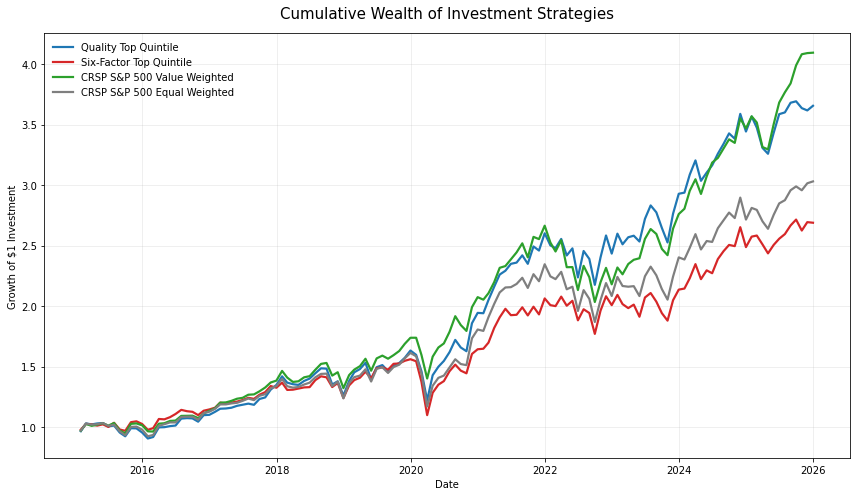

Cumulative wealth figure was saved successfully.


In [36]:
fig, axis = plt.subplots(
    figsize=(12, 7)
)

plot_dates = cumulative_wealth_df.index.to_numpy()

for column in cumulative_wealth_df.columns:
    plot_values = (
        cumulative_wealth_df[column]
        .to_numpy(dtype=float)
    )

    axis.plot(
        plot_dates,
        plot_values,
        label=column,
        color=color_mapping[column],
        linewidth=2.2
    )

axis.set_title(
    "Cumulative Wealth of Investment Strategies",
    fontsize=15,
    pad=15
)

axis.set_xlabel("Date")
axis.set_ylabel("Growth of $1 Investment")

axis.legend(
    frameon=False,
    loc="upper left"
)

axis.grid(alpha=0.25)

fig.tight_layout()

CUMULATIVE_WEALTH_FIGURE = (
    FIGURE_DIR
    / "01_cumulative_wealth_2015_2025.png"
)

fig.savefig(
    CUMULATIVE_WEALTH_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cumulative wealth figure was saved successfully.")

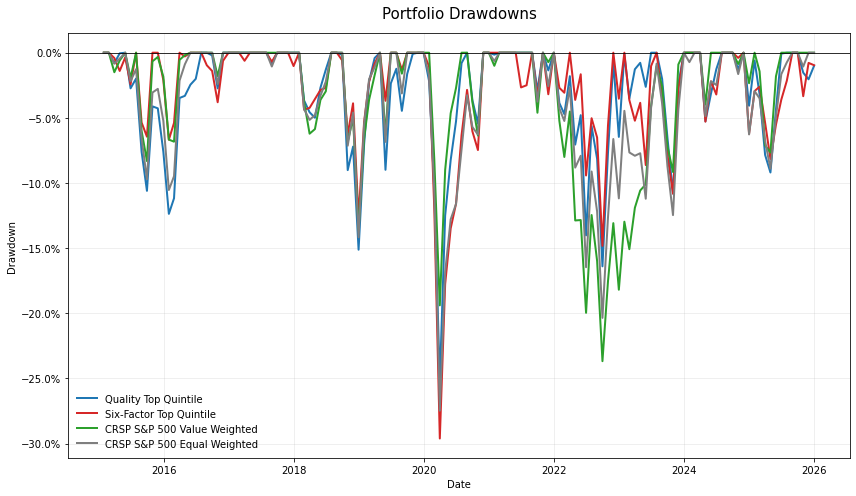

Drawdown figure was saved successfully.


In [39]:
from matplotlib.ticker import PercentFormatter

drawdown_df = (
    cumulative_wealth_df
    / cumulative_wealth_df.cummax()
    - 1.0
)

fig, axis = plt.subplots(
    figsize=(12, 7)
)

plot_dates = drawdown_df.index.to_numpy()

for column in drawdown_df.columns:
    plot_values = (
        drawdown_df[column]
        .to_numpy(dtype=float)
    )

    axis.plot(
        plot_dates,
        plot_values,
        label=column,
        color=color_mapping[column],
        linewidth=2.0
    )

axis.axhline(
    y=0,
    color="black",
    linewidth=0.8
)

axis.set_title(
    "Portfolio Drawdowns",
    fontsize=15,
    pad=15
)

axis.set_xlabel("Date")
axis.set_ylabel("Drawdown")

axis.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

axis.legend(
    frameon=False,
    loc="lower left"
)

axis.grid(alpha=0.25)

fig.tight_layout()

DRAWDOWN_FIGURE = (
    FIGURE_DIR
    / "02_portfolio_drawdowns_2015_2025.png"
)

fig.savefig(
    DRAWDOWN_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Drawdown figure was saved successfully.")

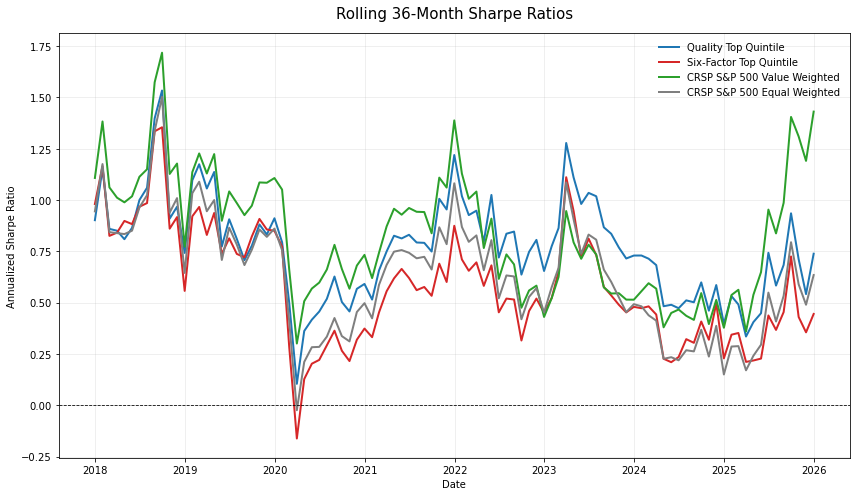

Rolling Sharpe-ratio figure was saved successfully.


In [40]:
rolling_window = 36

monthly_risk_free_rate = (
    evaluation_return_df
    .set_index("return_month")["rf"]
)

rolling_excess_return_df = (
    plot_return_df
    .sub(
        monthly_risk_free_rate,
        axis=0
    )
)

rolling_mean_excess_return_df = (
    rolling_excess_return_df
    .rolling(
        window=rolling_window,
        min_periods=rolling_window
    )
    .mean()
)

rolling_volatility_df = (
    rolling_excess_return_df
    .rolling(
        window=rolling_window,
        min_periods=rolling_window
    )
    .std(ddof=1)
)

rolling_sharpe_df = (
    rolling_mean_excess_return_df
    / rolling_volatility_df
    * np.sqrt(12.0)
)

fig, axis = plt.subplots(
    figsize=(12, 7)
)

plot_dates = rolling_sharpe_df.index.to_numpy()

for column in rolling_sharpe_df.columns:
    plot_values = (
        rolling_sharpe_df[column]
        .to_numpy(dtype=float)
    )

    axis.plot(
        plot_dates,
        plot_values,
        label=column,
        color=color_mapping[column],
        linewidth=2.0
    )

axis.axhline(
    y=0,
    color="black",
    linewidth=0.8,
    linestyle="--"
)

axis.set_title(
    "Rolling 36-Month Sharpe Ratios",
    fontsize=15,
    pad=15
)

axis.set_xlabel("Date")
axis.set_ylabel("Annualized Sharpe Ratio")

axis.legend(
    frameon=False,
    loc="best"
)

axis.grid(alpha=0.25)

fig.tight_layout()

ROLLING_SHARPE_FIGURE = (
    FIGURE_DIR
    / "03_rolling_36_month_sharpe_2015_2025.png"
)

fig.savefig(
    ROLLING_SHARPE_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Rolling Sharpe-ratio figure was saved successfully.")

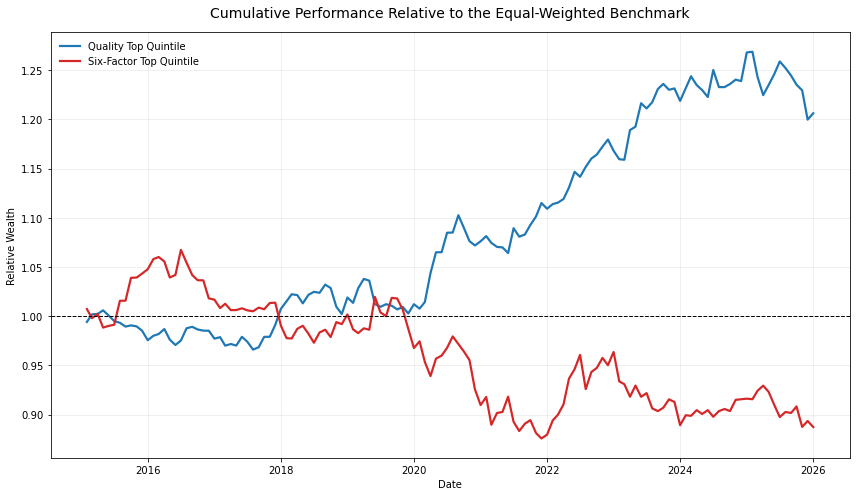

Relative-performance figure was saved successfully.


In [41]:
quality_relative_monthly_growth = (
    (
        1.0
        + evaluation_return_df[
            "quality_top_quintile_net"
        ]
    )
    /
    (
        1.0
        + evaluation_return_df[
            "crsp_equal_weighted_total_return"
        ]
    )
)

six_factor_relative_monthly_growth = (
    (
        1.0
        + evaluation_return_df[
            "six_factor_top_quintile_net"
        ]
    )
    /
    (
        1.0
        + evaluation_return_df[
            "crsp_equal_weighted_total_return"
        ]
    )
)

quality_relative_wealth = (
    quality_relative_monthly_growth
    .cumprod()
)

six_factor_relative_wealth = (
    six_factor_relative_monthly_growth
    .cumprod()
)

relative_wealth_df = pd.DataFrame({
    "return_month":
        evaluation_return_df[
            "return_month"
        ],

    "Quality Top Quintile":
        quality_relative_wealth,

    "Six-Factor Top Quintile":
        six_factor_relative_wealth
})

relative_wealth_df = (
    relative_wealth_df
    .set_index("return_month")
)

fig, axis = plt.subplots(
    figsize=(12, 7)
)

plot_dates = relative_wealth_df.index.to_numpy()

axis.plot(
    plot_dates,
    relative_wealth_df[
        "Quality Top Quintile"
    ].to_numpy(dtype=float),
    label="Quality Top Quintile",
    color="#1f77b4",
    linewidth=2.2
)

axis.plot(
    plot_dates,
    relative_wealth_df[
        "Six-Factor Top Quintile"
    ].to_numpy(dtype=float),
    label="Six-Factor Top Quintile",
    color="#d62728",
    linewidth=2.2
)

axis.axhline(
    y=1.0,
    color="black",
    linewidth=1.0,
    linestyle="--"
)

axis.set_title(
    "Cumulative Performance Relative to the Equal-Weighted Benchmark",
    fontsize=14,
    pad=15
)

axis.set_xlabel("Date")
axis.set_ylabel("Relative Wealth")

axis.legend(
    frameon=False,
    loc="best"
)

axis.grid(alpha=0.25)

fig.tight_layout()

RELATIVE_PERFORMANCE_FIGURE = (
    FIGURE_DIR
    / "04_relative_performance_vs_equal_weight_2015_2025.png"
)

fig.savefig(
    RELATIVE_PERFORMANCE_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Relative-performance figure was saved successfully.")